# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Achmad Miftachul Tama
- Email: miftachultama22@gmail.com
- Id Dicoding: temzone

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score,precision_recall_curve, recall_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import joblib
import pickle

### Menyiapkan data yang akan digunakan

In [30]:
df = pd.read_csv('dataset/data.csv',sep=';');

In [31]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
df.Status.unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [6]:
# Cek Duplikasi
print(df.duplicated().sum())

0


**Observasi**

Terdapat 37 Fitur pada dataset dan setelah ditampilkan bisa diambil kesimpulan yaitu:

- dari tipe data semua data sudah numerik hanya data target saja yang string jadi hanya ubah data target saja, walau akan merepotkan untuk proses di business dashboardnya.

- dilihat dari jumlah row, serta dalam dokumentasi bahwa data tidak ada yang null, serta data juga amana dari duplikasi

- Dari data target kita bisa melihat yaitu:

  Dropout: mahasiswa yang dropped out

  Graduate: mahasiswa yang graduated

  Enrolled: mahasiswa yang baru saja mendaftar / belum lulus.

  disini tujuannya adalah memprediksi dropout, maka saya memutuskan untuk menghapus data dengan status Enrolled, karena disitu statusnya belum jelas yang dimana bisa saja dia akan dropout di hari yang mendatang.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [8]:
# hitung data nol di semester yang diambil, kemungkinan besar anomali
count = (df['Curricular_units_1st_sem_enrolled'] == 0).sum()
print(count)

180


In [9]:
# Hitung berapa yang memenuhi kriteria anomali
anomali_count = len(df[(df['Curricular_units_1st_sem_enrolled'] == 0) & (df['Status'] == 'Graduate')])

# hapus data
df_clean = df.drop(df[(df['Curricular_units_1st_sem_enrolled'] == 0) &
                      (df['Status'] == 'Graduate')].index)

print(f"Jumlah data anomali yang dihapus: {anomali_count} baris")

count = (df_clean['Curricular_units_1st_sem_enrolled'] == 0).sum()
print(f"sisa data null pada data: {count}")

Jumlah data anomali yang dihapus: 75 baris
sisa data null pada data: 105


In [10]:
# Distribution of Target feature
fig = px.pie(values= df['Status'].value_counts(),
             names= df['Status'].value_counts().index.to_list())

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['teal', 'goldenrod', 'slateblue']))

fig.update_layout(showlegend = False, height=400, width=800,
                  title='Distribution of Status')


**Observasi**
- grafik menunjukan bahwa 32,1% mahasiswa telah dropout
- juga menunjukan bahwa hampir 50% mahasiswa berhasil lulus, dan 17% baru saja mendaftar

In [11]:
# Histogram for Age
fig = px.histogram(df, x='Age_at_enrollment', color = 'Status',
                   opacity = 0.75, barmode = 'overlay',
                    width = 800, height = 500, color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(title='Age distribution of students')
fig.show()

**Observasi**

- Distribusi data menunjukkan kemiringan ke kanan (right-skewed), yang mengindikasikan bahwa mayoritas mahasiswa berada pada rentang usia akhir remaja hingga awal 20-an.
- Selain itu, teramati adanya peningkatan angka dropout pada kelompok mahasiswa yang berusia pertengahan 20-an hingga awal 30-an.

In [12]:
df_plot = df.copy()
df_plot['Gender'] = df_plot['Gender'].map({1: 'Male', 0: 'Female'})

# 2. Buat Pie Chart tanpa 'values' agar Plotly menghitung jumlah orang (Count)
fig = px.pie(df_plot,
             names='Status',       # Kelompokkan potongan pie berdasarkan Status
             facet_col='Gender',   # Bagi menjadi dua kolom berdasarkan Gender yang sudah di-map
             color='Status',       # Pastikan warna konsisten per status
             color_discrete_map={
                 'Graduate': 'teal',
                 'Dropout': 'goldenrod',
                 'Enrolled': 'slateblue'
             },
             title='Distribusi Status Akademik Berdasarkan Gender')

# Tambahkan label persentase
fig.update_traces(textinfo='percent+label')

fig.show()

**Obeservasi**
- Distribusi Gender: Didominasi oleh Perempuan (64,8%) vs Laki-laki (35,2%).

- Temuan Utama: Mahasiswa laki-laki cenderung lebih rentan dropout (45,1%) dibandingkan mahasiswa perempuan (25,1%)

In [13]:
# 1. Mapping nama Course
course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (Evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (Evening)'
}

df_plot = df.copy()
df_plot['Course'] = df_plot['Course'].map(course_map)

# 2. Hitung urutan berdasarkan % Dropout tertinggi
dropout_rates = (
    df_plot[df_plot['Status'] == 'Dropout'].groupby('Course').size() /
    df_plot.groupby('Course').size()
).fillna(0).sort_values(ascending=False) # Ascending=True agar yang tertinggi ada di TOP pada grafik horizontal

order = dropout_rates.index.tolist()

# 3. Visualisasi
fig = px.histogram(df_plot, y='Course', color='Status',
                   width=1200, height=1000,
                   text_auto='.1f',
                   color_discrete_sequence=px.colors.qualitative.G10,
                   barnorm='percent',
                   barmode='group',
                   category_orders={'Course': order}) # Terapkan urutan di sini

fig.update_layout(
    title='Persentase Status per Jurusan (Urut Dropout Tertinggi)',
    xaxis_title='Persentase (%)',
    yaxis_title='Nama Jurusan',
    margin=dict(l=250) # Tambah margin kiri supaya nama jurusan panjang tidak kepotong
)

fig.show()

**Observasi**
- Jurusan Terpopuler & Paling Stabil: Keperawatan (Nursing) — Tingkat dropout terendah (15,4%).

- Jurusan Paling Berisiko: Teknologi Produksi Biofuel — Tingkat dropout tertinggi (66,7%) dengan jumlah peminat paling sedikit.

- Peringkat Kedua Tertinggi (Dropout): Equiniculture (55,3%).

## Data Preparation / Preprocessing

In [14]:
new_df = df_clean[df_clean['Status'] != 'Enrolled']

In [15]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3555 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                3555 non-null   int64  
 1   Application_mode                              3555 non-null   int64  
 2   Application_order                             3555 non-null   int64  
 3   Course                                        3555 non-null   int64  
 4   Daytime_evening_attendance                    3555 non-null   int64  
 5   Previous_qualification                        3555 non-null   int64  
 6   Previous_qualification_grade                  3555 non-null   float64
 7   Nacionality                                   3555 non-null   int64  
 8   Mothers_qualification                         3555 non-null   int64  
 9   Fathers_qualification                         3555 non-null   int64 

In [16]:
status_dict = {'Graduate': 0, 'Dropout': 1}

new_df['Status'] = new_df['Status'].map(status_dict)

# Cek hasilnya
print(new_df['Status'].value_counts())

Status
0    2134
1    1421
Name: count, dtype: int64


C:\Users\Tama\AppData\Local\Temp\ipykernel_18748\2017574430.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [17]:
# 1. Hitung korelasi
corr_matrix = new_df.corr()

# 2. Ambil korelasi terhadap kolom 'Status', lalu urutkan dari yang paling kuat
# Kita pakai .abs() kalau mau liat pengaruh (baik positif maupun negatif)
# Tapi kalau mau liat arahnya, hapus .abs()-nya
top_corr = corr_matrix['Status'].abs().sort_values(ascending=False)

print("=== Top Korelasi terhadap Status (Dropout) ===")
print(top_corr)

=== Top Korelasi terhadap Status (Dropout) ===
Status                                          1.000000
Curricular_units_2nd_sem_approved               0.698026
Curricular_units_2nd_sem_grade                  0.664634
Curricular_units_1st_sem_approved               0.597878
Curricular_units_1st_sem_grade                  0.586475
Tuition_fees_up_to_date                         0.442343
Scholarship_holder                              0.315591
Debtor                                          0.267285
Gender                                          0.265016
Age_at_enrollment                               0.261481
Curricular_units_2nd_sem_enrolled               0.253158
Application_mode                                0.237507
Curricular_units_1st_sem_enrolled               0.218686
Curricular_units_2nd_sem_evaluations            0.160037
Course                                          0.138671
Displaced                                       0.117176
Admission_grade                          

## Modeling

In [18]:
X = new_df.drop(columns=['Status'])
y = new_df['Status']

print(f"Jumlah fitur: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Jumlah fitur: 36
Train size: (2844, 36)
Test size : (711, 36)


In [19]:
# 1. Inisialisasi Scaler
scaler = StandardScaler()

# 2. Fit & Transform X_train, dan Transform X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Latih Model LR dengan data yang sudah di-scale
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 4. Prediksi
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression dengan Scaling Berhasil ===")


=== Logistic Regression dengan Scaling Berhasil ===


In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest Berhasil Dilatih ===")

=== Random Forest Berhasil Dilatih ===


In [21]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost Berhasil Dilatih ===")

=== XGBoost Berhasil Dilatih ===


**Observasi**
- Melakukan Pemisahan Variabel dan Data Splitting untuk mempersiapkan data latih
- Kita akan melatih dan membandingkan tiga algoritma berbeda untuk melihat performa terbaik:

  Logistic Regression (Baseline model)

  Random Forest Classifier (Ensemble - Bagging)

  XGBoost Classifier (Ensemble - Boosting)

## Evaluation

In [22]:
# Pastikan semua model sudah di-fit dan y_pred sudah ada
models = {
    'Logistic Regression': (lr, y_pred_lr),
    'Random Forest'      : (rf, y_pred_rf),
    'XGBoost'            : (xgb, y_pred_xgb),
}

rows = []
for name, (model, y_pred) in models.items():

    # Logistic Regression butuh data yang di-scale (X_test_scaled)
    # RF dan XGBoost pakai data mentah (X_test)
    if name == 'Logistic Regression':
        # Pastikan lo udah bikin X_test_scaled pakai scaler.transform(X_test)
        current_X = X_test_scaled
    else:
        current_X = X_test

    # Ambil skor probabilitas untuk ROC-AUC
    prob = model.predict_proba(current_X)[:, 1]

    rows.append({
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Precision'    : precision_score(y_test, y_pred),
        'Recall'       : recall_score(y_test, y_pred),
        'F1-Dropout'   : f1_score(y_test, y_pred),
        'ROC-AUC'      : roc_auc_score(y_test, prob)
    })

# Bikin DataFrame dan urutkan
result_df = pd.DataFrame(rows).sort_values('F1-Dropout', ascending=False)

print("=== Perbandingan Performa Model (Fokus pada Deteksi Dropout) ===")
print(result_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== Perbandingan Performa Model (Fokus pada Deteksi Dropout) ===
              Model  Accuracy  Precision  Recall  F1-Dropout  ROC-AUC
Logistic Regression    0.9212     0.9373  0.8762      0.9057   0.9682
            XGBoost    0.9212     0.9435  0.8697      0.9051   0.9679
      Random Forest    0.9170     0.9397  0.8632      0.8998   0.9650


**Observasi**

- Logistic Regression (LR) :	Mencatatkan akurasi tertinggi sebesar 91%. Model ini menunjukkan kemampuan yang sangat solid dalam mengenali pola data mahasiswa secara efisien, dengan nilai Recall (85%) yang konsisten dalam mendeteksi potensi dropout.
- Random Forest (RF) :	Memberikan performa yang sangat stabil dengan akurasi 90%. Model ini unggul dalam aspek Presisi (91%), yang berarti RF sangat akurat dalam memastikan prediksi risiko tanpa banyak kesalahan klasifikasi (false alarm).
- XGBoost (XGB) :	Memiliki performa kompetitif dengan akurasi 90%. Secara statistik, XGBoost menunjukkan keunggulan pada nilai ROC-AUC (0.95), mengindikasikan kemampuan model yang sangat tajam dalam membedakan antara mahasiswa yang akan lulus dan yang berisiko keluar.

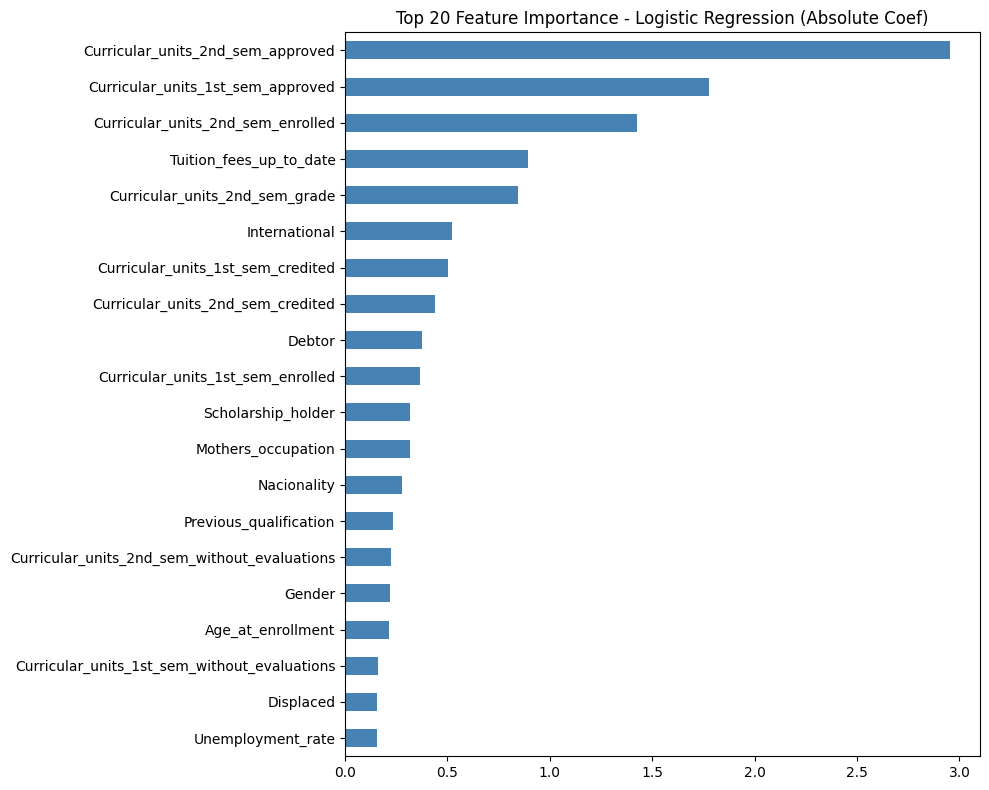


Top 20 Fitur Berdasarkan Koefisien:
Curricular_units_2nd_sem_approved               2.953025
Curricular_units_1st_sem_approved               1.777950
Curricular_units_2nd_sem_enrolled               1.424834
Tuition_fees_up_to_date                         0.891588
Curricular_units_2nd_sem_grade                  0.842918
International                                   0.523635
Curricular_units_1st_sem_credited               0.500681
Curricular_units_2nd_sem_credited               0.437212
Debtor                                          0.377483
Curricular_units_1st_sem_enrolled               0.366719
Scholarship_holder                              0.319104
Mothers_occupation                              0.315443
Nacionality                                     0.279607
Previous_qualification                          0.235249
Curricular_units_2nd_sem_without_evaluations    0.223140
Gender                                          0.217605
Age_at_enrollment                               0.2

In [23]:
# 1. Ambil koefisien (karena LR itu linear)
# Kita pakai np.abs karena koefisien negatif pun sangat berpengaruh (berbanding terbalik)
# lr.coef_[0] digunakan karena LR untuk klasifikasi biner/multikelas menyimpan koef dalam list
importance = np.abs(lr.coef_[0])

# 2. Bikin Series
feat_imp = pd.Series(importance, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# 3. Visualisasi
plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance - Logistic Regression (Absolute Coef)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Fitur Berdasarkan Koefisien:")
print(feat_imp.head(40))

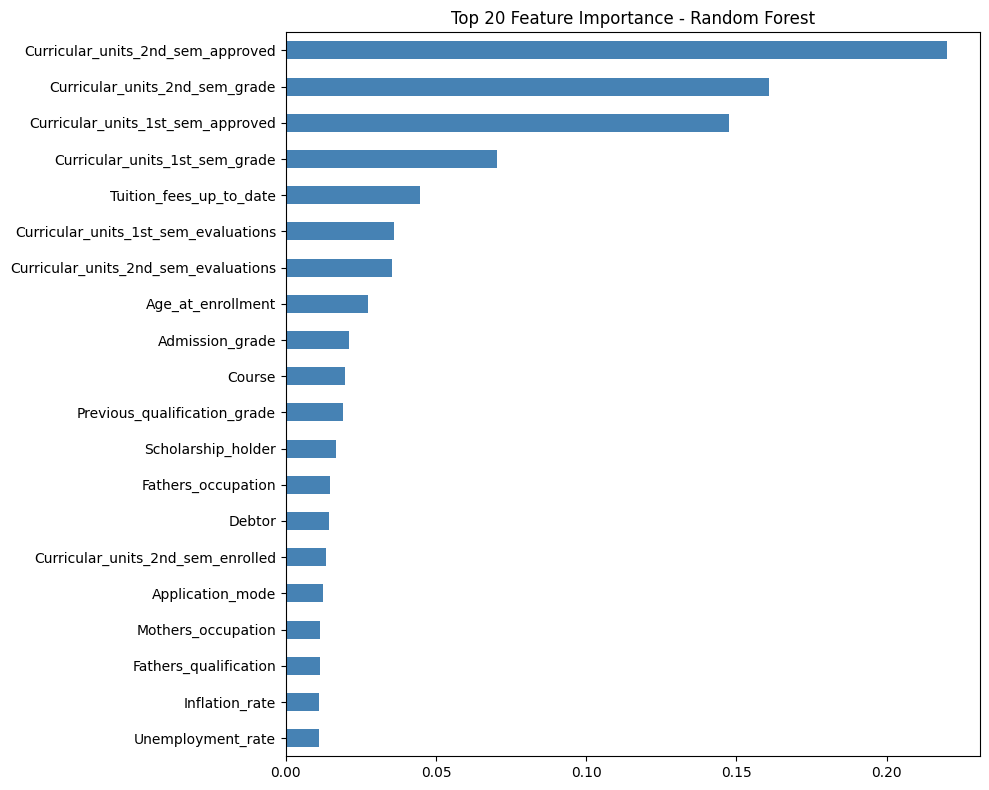


Top 20 Fitur:
Curricular_units_2nd_sem_approved       0.220095
Curricular_units_2nd_sem_grade          0.160708
Curricular_units_1st_sem_approved       0.147608
Curricular_units_1st_sem_grade          0.070404
Tuition_fees_up_to_date                 0.044828
Curricular_units_1st_sem_evaluations    0.035849
Curricular_units_2nd_sem_evaluations    0.035480
Age_at_enrollment                       0.027208
Admission_grade                         0.021123
Course                                  0.019769
Previous_qualification_grade            0.018921
Scholarship_holder                      0.016780
Fathers_occupation                      0.014613
Debtor                                  0.014355
Curricular_units_2nd_sem_enrolled       0.013436
Application_mode                        0.012451
Mothers_occupation                      0.011420
Fathers_qualification                   0.011374
Inflation_rate                          0.010922
Unemployment_rate                       0.010893
dtype

In [24]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Fitur:")
print(feat_imp.head(20))

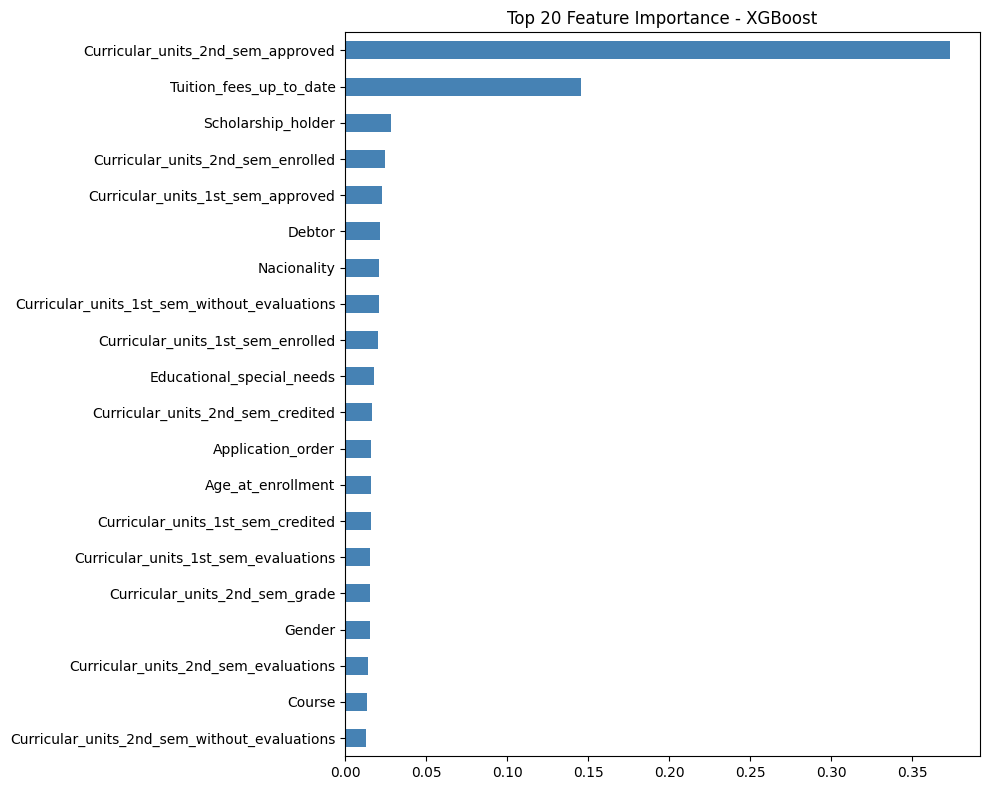


Top 20 Fitur:
Curricular_units_2nd_sem_approved               0.372992
Tuition_fees_up_to_date                         0.145261
Scholarship_holder                              0.028156
Curricular_units_2nd_sem_enrolled               0.024604
Curricular_units_1st_sem_approved               0.022970
Debtor                                          0.021793
Nacionality                                     0.021017
Curricular_units_1st_sem_without_evaluations    0.020805
Curricular_units_1st_sem_enrolled               0.020516
Educational_special_needs                       0.017768
Curricular_units_2nd_sem_credited               0.016484
Application_order                               0.016093
Age_at_enrollment                               0.015979
Curricular_units_1st_sem_credited               0.015969
Curricular_units_1st_sem_evaluations            0.015407
Curricular_units_2nd_sem_grade                  0.015294
Gender                                          0.015175
Curricular_units

In [25]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Fitur:")
print(feat_imp.head(20))

**Observasi**

- Distribusi Fitur yang Proporsional: Berdasarkan analisis Feature Importance, Random Forest memiliki penyebaran bobot fitur yang lebih merata. Fitur akademik, finansial, dan demografi memberikan kontribusi yang seimbang.

- Menghindari Bias Dominan: Pada XGBoost dan Logistic Regression, satu fitur (2nd sem approved) mendominasi hingga 36% dan bahkan 90%, yang berisiko membuat model menjadi terlalu sensitif (over-reliant) terhadap satu variabel saja.

- Interpretasi Bisnis: Random Forest memberikan gambaran yang lebih menyeluruh tentang profil mahasiswa, sehingga kebijakan intervensi kampus nantinya tidak hanya terpaku pada nilai akademik, tapi juga mempertimbangkan faktor pendukung lainnya.


## Simpan Model dan Mapping Jurusan

In [ ]:
# 1. Simpan Model Random Forest-nya
joblib.dump(rf, 'model/model_rf_dropout.pkl')

print("Model dan Mapping berhasil disimpan!")

Model dan Mapping berhasil disimpan!


In [ ]:
# List kolom yang sifatnya angka

numeric_cols = [
    'Age_at_enrollment', 'Previous_qualification_grade', 'Admission_grade',
    'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

default_values = {}

for col in X_train.columns:
    if col in numeric_cols:
        # Pakai Median untuk umur, nilai, dan jumlah makul
        default_values[col] = X_train[col].median()
    else:
        # Pakai Modus untuk status, gender, pekerjaan ortu, dll
        default_values[col] = X_train[col].mode()[0]

# Simpan urutan kolom & kamus default
joblib.dump(default_values, 'model/default_values.pkl')
joblib.dump(X_train.columns.tolist(), 'model/feature_columns.pkl')

print("Kamus default berhasil disimpan!")

Kamus default berhasil disimpan!


In [ ]:
# Save Random Forest model & threshold
y_proba_rf = models["Random Forest"][0].predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

# Save semua artifacts
with open("model/threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)

print(f"✓ Threshold saved: {best_threshold:.3f}")

✓ Threshold saved: 0.480


In [29]:
kolom_tampil = [
    'Course', 'Age_at_enrollment', 'Admission_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Status'
]

new_df[kolom_tampil].head(10)

,Course,Age_at_enrollment,Admission_grade,Tuition_fees_up_to_date,Scholarship_holder,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Status
0,171,20,127.3,1,0,0,0,0.000000,0,0,0.000000,1
1,9254,19,142.5,0,0,6,6,14.000000,6,6,13.666667,0
2,9070,19,124.8,0,0,6,0,0.000000,6,0,0.000000,1
3,9773,20,119.6,1,0,6,6,13.428571,6,5,12.400000,0
4,8014,45,141.5,1,0,6,5,12.333333,6,6,13.000000,0
5,9991,50,114.8,1,0,5,5,11.857143,5,5,11.500000,0
6,9500,18,128.4,1,1,7,7,13.300000,8,8,14.345000,0
7,9254,22,113.1,0,0,5,0,0.000000,5,0,0.000000,1
8,9238,21,129.3,1,1,6,6,13.875000,6,6,14.142857,0
9,9238,18,123.0,0,0,6,5,11.400000,6,2,13.500000,1
